In [194]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from sklearn.preprocessing import StandardScaler

Decide which features have normal distribution and then use proper test for statistical significance

In [186]:
# Load all merged spine datasets
df_l_c25 = pd.read_csv(r"D:\DP\CSV\merged_CaSupp_25_radiomics_spine_lesions_features.csv")
df_l_konv = pd.read_csv(r"D:\DP\CSV\merged_konv_radiomics_spine_lesions_features.csv")
df_l_vmi40 = pd.read_csv(r"D:\DP\CSV\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
df_l_vmi80 = pd.read_csv(r"D:\DP\CSV\merged_monoe_80kev_radiomics_spine_lesions_features.csv")
df_l_vmi120 = pd.read_csv(r"D:\DP\CSV\merged_monoe_120kev_radiomics_spine_lesions_features.csv")

NORMALITY DISTRIBUTION TEST

p > 0.05 -> normal distribution || p ≤ 0.05 -> not normal distribution

In [187]:
def normality_distribution(dataset, cols_to_drop):
    normal_distribution = []
    non_normal_distribution = []

    dataset = dataset.drop(columns=cols_to_drop)

    for column in dataset.columns:
        _, p_val = shapiro(dataset[column])
        if p_val > 0.05:
            normal_distribution.append(column)
        else:
            non_normal_distribution.append(column)

    return normal_distribution, non_normal_distribution

In [201]:
normal_features, non_normal_features = normality_distribution(df_l_vmi120, ["patient"])

print(f"Number of normal features: {len(normal_features)}")
print(f"Number of non-normal features: {len(non_normal_features)}")

Number of normal features: 59
Number of non-normal features: 142


In [202]:
def select_uncorrelated_features(dataset, features, thr=0.6, method='pearson', standardize=True):
    df = dataset[features].copy()

    if standardize:
        scaler = StandardScaler()
        df[df.columns] = scaler.fit_transform(df)

    corr_matrix = df.corr(method=method).abs()  # absolute correlation
    to_drop = set()
    # Compute average correlation for each feature
    avg_corr = corr_matrix.mean()

    # Go through upper triangle to find correlated pairs
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            f1 = corr_matrix.columns[i]
            f2 = corr_matrix.columns[j]
            r = corr_matrix.loc[f1, f2]
            if r > thr:
                # Drop the one with higher average correlation
                if avg_corr[f1] > avg_corr[f2]:
                    to_drop.add(f1)
                else:
                    to_drop.add(f2)

    selected_features = [f for f in features if f not in to_drop]
    return selected_features

filtered_normal_features = select_uncorrelated_features(df_l_vmi120, normal_features)
filtered_non_normal_features = select_uncorrelated_features(df_l_vmi120, non_normal_features, method='spearman')

print(f"Number of normal filtered features: {len(filtered_normal_features)}")
print(f"Number of non-normal filtered features: {len(filtered_non_normal_features)}")

Number of normal filtered features: 11
Number of non-normal filtered features: 14


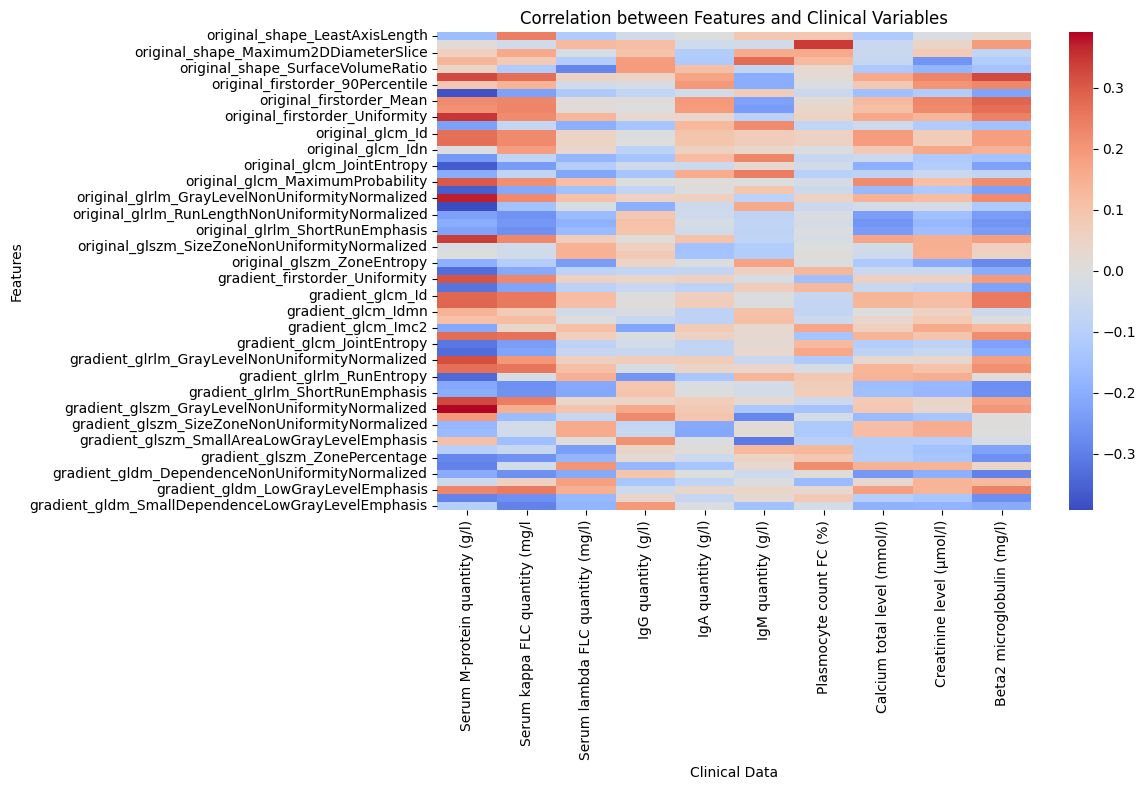

In [206]:
df_clinical = pd.read_csv(r"D:\DP\Table_clinical_data.csv", encoding="cp1252")
drop_columns = ["Patient ID", "line of treatment", "M-protein type", "Light chain type",
                "Flow cytometry – circulating plasma cells (peripheral blood)", "ISS classification",
                "Treatment regimen", "Maximal response to treatment", "MM associated amyloidosis", "Follow - up"]

df_clinical = df_clinical.drop(columns=drop_columns)

corr_matrix = pd.DataFrame(index=df_l_vmi120[normal_features].columns, columns=df_clinical.columns)

for f_col in df_l_vmi120[normal_features].columns:
    for c_col in df_clinical.columns:
        corr_matrix.loc[f_col, c_col] = df_l_vmi120[normal_features][f_col].corr(df_clinical[c_col], method='pearson')

corr_matrix = corr_matrix.astype(float)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title("Correlation between Features and Clinical Variables")
plt.xlabel("Clinical Data")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [ ]:
# TODO: Divide features based on their normality distribution (normal/non-normal)
# TODO: Clear clinical data from Nan and outliers
# TODO: Divide clinical data based on their normality distribution
# TODO: Standardized features and also clinical data
# TODO: Compute heatmaps for each image type